#ÉTAPE 1 : Planification de l'architecture, Configuration de l'environnement PySpark & Fondations de Big Data

In [26]:

# 1. INSTALLATION DES DÉPENDANCES (Google Colab)

!apt-get install openjdk-8-jdk-headless -qq > /dev/null
!pip install -q pyspark

# 2. CONFIGURATION ET INITIALISATION DE LA SPARK SESSION

from pyspark.sql import SparkSession

# Création d'une SparkSession (Le point d'entrée de notre application Spark)
spark = SparkSession.builder \
    .appName("Football_Data_Engineering_Pipeline") \
    .master("local[*]") \
    .config("spark.sql.shuffle.partitions", "5") \
    .getOrCreate()

# Vérification de la session
print("Spark Session initialisée avec succès !")
print(f"Version de Spark utilisée : {spark.version}")

Spark Session initialisée avec succès !
Version de Spark utilisée : 4.0.2


#ÉTAPE 2 : Chargement, Exploration et Préparation de la Couche "Raw" (Bronze)


In [27]:
from pyspark.sql.types import IntegerType

# 1. INGESTION DU FICHIER CSV (Couche Bronze)

# Chargement du dataset avec inférence du schéma et présence d'en-têtes
df_raw = spark.read.csv("/content/drive/MyDrive/Colab Notebooks/football_data_project/ensemble-de-donnees.csv", header=True, inferSchema=True)

# Affichage du schéma du DataFrame

print("--- Schéma initial du fichier CSV ---")
df_raw.printSchema()


# 2. NETTOYAGE : SÉLECTION, RENOMMAGE ET SUPPRESSION DE COLONNES

# Le brief nous demande de comprendre, renommer et nettoyer.
# Nous allons renommer les colonnes de buts et de résultats pour plus de clarté
# et supprimer 'Match_ID' et 'Date' qui ne serviront pas pour les agrégations de performance.

df_cleaned = df_raw \
    .withColumnRenamed("FTHG", "HomeTeamGoals") \
    .withColumnRenamed("FTAG", "AwayTeamGoals") \
    .withColumnRenamed("FTR", "FinalResult") \
    .drop("Match_ID", "Date")

print("\n--- Schéma après nettoyage et renommage ---")
df_cleaned.printSchema()



--- Schéma initial du fichier CSV ---
root
 |-- Match_ID: integer (nullable = true)
 |-- Div: string (nullable = true)
 |-- Season: integer (nullable = true)
 |-- Date: date (nullable = true)
 |-- HomeTeam: string (nullable = true)
 |-- AwayTeam: string (nullable = true)
 |-- FTHG: integer (nullable = true)
 |-- FTAG: integer (nullable = true)
 |-- FTR: string (nullable = true)


--- Schéma après nettoyage et renommage ---
root
 |-- Div: string (nullable = true)
 |-- Season: integer (nullable = true)
 |-- HomeTeam: string (nullable = true)
 |-- AwayTeam: string (nullable = true)
 |-- HomeTeamGoals: integer (nullable = true)
 |-- AwayTeamGoals: integer (nullable = true)
 |-- FinalResult: string (nullable = true)



In [28]:
# Action pour visualiser les 5 premières lignes
print("\n--- Aperçu des 5 premières lignes du DataFrame nettoyé ---")
df_cleaned.show(5)


--- Aperçu des 5 premières lignes du DataFrame nettoyé ---
+---+------+-------------+--------------+-------------+-------------+-----------+
|Div|Season|     HomeTeam|      AwayTeam|HomeTeamGoals|AwayTeamGoals|FinalResult|
+---+------+-------------+--------------+-------------+-------------+-----------+
| D2|  2009|   Oberhausen|Kaiserslautern|            2|            1|          H|
| D2|  2009|  Munich 1860|Kaiserslautern|            0|            1|          A|
| D2|  2009|Frankfurt FSV|Kaiserslautern|            1|            1|          D|
| D2|  2009|Frankfurt FSV|     Karlsruhe|            2|            1|          H|
| D2|  2009|        Ahlen|     Karlsruhe|            1|            3|          A|
+---+------+-------------+--------------+-------------+-------------+-----------+
only showing top 5 rows


#ÉTAPE 3 : Création de colonnes indicatrices et Filtrage stratégique

3-1. CRÉATION DES COLONNES INDICATRICES (withColumn + when/otherwise)

In [29]:
from pyspark.sql.functions import col, when

# FinalResult contient : 'H' (Home win), 'A' (Away win), 'D' (Draw/Match nul)

df_with_flags = df_cleaned \
    .withColumn("HomeTeamWin", when(col("FinalResult") == "H", 1).otherwise(0)) \
    .withColumn("AwayTeamWin", when(col("FinalResult") == "A", 1).otherwise(0)) \
    .withColumn("GameTie", when(col("FinalResult") == "D", 1).otherwise(0))

3-2. FILTRAGE : BUNDESLIGA (D1) ET SAISONS 2000 À 2015

In [30]:
# Application des filtres demandés par le brief
df_filtered = df_with_flags.filter(
    (col("Div") == "D1") &
    (col("Season") >= 2000) &
    (col("Season") <= 2015)
)

# Optionnel mais propre : On supprime la colonne 'Div' car elle ne contient plus que 'D1'
df_filtered = df_filtered.drop("Div")

In [31]:
df_filtered.toPandas()

,Season,HomeTeam,AwayTeam,HomeTeamGoals,AwayTeamGoals,FinalResult,HomeTeamWin,AwayTeamWin,GameTie
0,2009,Bochum,Leverkusen,1,1,D,0,0,1
1,2009,Bayern Munich,Leverkusen,1,1,D,0,0,1
2,2009,M'gladbach,Leverkusen,1,1,D,0,0,1
3,2009,Mainz,Leverkusen,2,2,D,0,0,1
4,2009,Hamburg,Leverkusen,0,0,D,0,0,1
...,...,...,...,...,...,...,...,...,...
4891,2004,Hertha,Hannover,0,0,D,0,0,1
4892,2004,Kaiserslautern,Werder Bremen,1,2,A,0,1,0
4893,2004,Leverkusen,M'gladbach,5,1,H,1,0,0
4894,2004,Nurnberg,Mainz,1,2,A,0,1,0


3-3. VÉRIFICATION DES RÉSULTATS

In [32]:
print("--- Nombre de matchs après filtrage ---")
print(f"Total de lignes restantes : {df_filtered.count()}")

print("\n--- Aperçu des indicateurs créés (5 premières lignes) ---")
df_filtered.select("HomeTeam", "AwayTeam", "FinalResult", "HomeTeamWin", "AwayTeamWin", "GameTie").show(5)

--- Nombre de matchs après filtrage ---
Total de lignes restantes : 4896

--- Aperçu des indicateurs créés (5 premières lignes) ---
+-------------+----------+-----------+-----------+-----------+-------+
|     HomeTeam|  AwayTeam|FinalResult|HomeTeamWin|AwayTeamWin|GameTie|
+-------------+----------+-----------+-----------+-----------+-------+
|       Bochum|Leverkusen|          D|          0|          0|      1|
|Bayern Munich|Leverkusen|          D|          0|          0|      1|
|   M'gladbach|Leverkusen|          D|          0|          0|      1|
|        Mainz|Leverkusen|          D|          0|          0|      1|
|      Hamburg|Leverkusen|          D|          0|          0|      1|
+-------------+----------+-----------+-----------+-----------+-------+
only showing top 5 rows


#ÉTAPE 4 : Les Agrégations Distribuées avec Group By et Agg

In [33]:
from pyspark.sql.functions import sum, count

# 1. AGRÉGATIONS POUR LES MATCHS À DOMICILE (Home Matches)

# On groupe par Saison et équipe à domicile
df_home_matches = df_filtered.groupBy("Season", "HomeTeam") \
    .agg(
        sum("HomeTeamWin").alias("HomeWin"),
        sum("AwayTeamWin").alias("HomeLoss"),  # Si l'équipe extérieure gagne, c'est une défaite à domicile
        sum("GameTie").alias("HomeTie"),
        sum("HomeTeamGoals").alias("HomeScoredGoals"),
        sum("AwayTeamGoals").alias("HomeAgainstGoals")
    )

In [34]:
# 2. AGRÉGATIONS POUR LES MATCHS À L'EXTÉRIEUR (Away Matches)

# On groupe par Saison et équipe à l'extérieur
df_away_matches = df_filtered.groupBy("Season", "AwayTeam") \
    .agg(
        sum("AwayTeamWin").alias("AwayWin"),
        sum("HomeTeamWin").alias("AwayLoss"),  # Si l'équipe à domicile gagne, c'est une défaite à l'extérieur
        sum("GameTie").alias("AwayTie"),
        sum("AwayTeamGoals").alias("AwayScoredGoals"),
        sum("HomeTeamGoals").alias("AwayAgainstGoals")
    )

In [35]:
# 3. VÉRIFICATION DES RÉSULTATS (Actions)

print("--- Aperçu des statistiques à domicile (Home) ---")
df_home_matches.show(5)

print("\n--- Aperçu des statistiques à l'extérieur (Away) ---")
df_away_matches.show(5)

--- Aperçu des statistiques à domicile (Home) ---
+------+----------+-------+--------+-------+---------------+----------------+
|Season|  HomeTeam|HomeWin|HomeLoss|HomeTie|HomeScoredGoals|HomeAgainstGoals|
+------+----------+-------+--------+-------+---------------+----------------+
|  2009|    Bochum|      2|       9|      6|             18|              35|
|  2009| Stuttgart|      8|       4|      5|             28|              21|
|  2009|Schalke 04|     11|       4|      2|             29|              15|
|  2009|  Freiburg|      5|       8|      4|             14|              26|
|  2009| Wolfsburg|      7|       8|      2|             39|              39|
+------+----------+-------+--------+-------+---------------+----------------+
only showing top 5 rows

--- Aperçu des statistiques à l'extérieur (Away) ---
+------+----------+-------+--------+-------+---------------+----------------+
|Season|  AwayTeam|AwayWin|AwayLoss|AwayTie|AwayScoredGoals|AwayAgainstGoals|
+------+------

#ÉTAPE 5 : La Fusion des DataFrames par Jointure (Join)

In [36]:
#1. EXÉCUTION DE LA JOINTURE (INNER JOIN)

# On joint sur la correspondance des saisons ET du nom de l'équipe
join_conditions = (df_home_matches.Season == df_away_matches.Season) & \
                  (df_home_matches.HomeTeam == df_away_matches.AwayTeam)

df_merged = df_home_matches.join(df_away_matches, on=join_conditions, how="inner")

In [37]:
#2. NETTOYAGE DES COLONNES DUPLIQUÉES APRÈS JOINTURE

# Après la jointure, nous avons des colonnes redondantes : deux fois la saison,
# et le nom de l'équipe s'appelle à la fois 'HomeTeam' et 'AwayTeam'.
# On sélectionne proprement les colonnes en renommant 'HomeTeam' par 'Team'.

df_merged = df_merged.select(
    df_home_matches.Season,
    df_home_matches.HomeTeam.alias("Team"),
    "HomeWin", "HomeLoss", "HomeTie", "HomeScoredGoals", "HomeAgainstGoals",
    "AwayWin", "AwayLoss", "AwayTie", "AwayScoredGoals", "AwayAgainstGoals"
)

In [38]:
#3. VÉRIFICATION DES RÉSULTATS (Action)

print("--- Nombre de lignes du DataFrame fusionné ---")
print(f"Total de lignes : {df_merged.count()}")

print("\n--- Aperçu du DataFrame fusionné (5 premières lignes) ---")
df_merged.show(5)

--- Nombre de lignes du DataFrame fusionné ---
Total de lignes : 288

--- Aperçu du DataFrame fusionné (5 premières lignes) ---
+------+----------+-------+--------+-------+---------------+----------------+-------+--------+-------+---------------+----------------+
|Season|      Team|HomeWin|HomeLoss|HomeTie|HomeScoredGoals|HomeAgainstGoals|AwayWin|AwayLoss|AwayTie|AwayScoredGoals|AwayAgainstGoals|
+------+----------+-------+--------+-------+---------------+----------------+-------+--------+-------+---------------+----------------+
|  2009|Schalke 04|     11|       4|      2|             29|              15|      8|       3|      6|             24|              16|
|  2009| Stuttgart|      8|       4|      5|             28|              21|      7|       5|      5|             23|              20|
|  2009|    Bochum|      2|       9|      6|             18|              35|      4|       9|      4|             15|              29|
|  2009| Wolfsburg|      7|       8|      2|            

#ÉTAPE 6 : Création des nouvelles colonnes synthétiques et KPIs Avancés

In [39]:
from pyspark.sql.functions import col, round


# 1. CALCUL DES COLONNES DE TOTAUX (Buts, Matchs, Victoires, Défaites, Nuls)

df_totals = df_merged \
    .withColumn("GoalsScored", col("HomeScoredGoals") + col("AwayScoredGoals")) \
    .withColumn("GoalsAgainst", col("HomeAgainstGoals") + col("AwayAgainstGoals")) \
    .withColumn("Win", col("HomeWin") + col("AwayWin")) \
    .withColumn("Loss", col("HomeLoss") + col("AwayLoss")) \
    .withColumn("Tie", col("HomeTie") + col("AwayTie"))

# Ajout du nombre total de matchs joués
df_totals = df_totals.withColumn("TotalGames", col("Win") + col("Loss") + col("Tie"))

In [40]:
#2. CALCUL DES KPIS AVANCÉS ET ARRONDIS (withColumn + round)

df_kpis = df_totals \
    .withColumn("GoalDifferentials", col("GoalsScored") - col("GoalsAgainst")) \
    .withColumn("WinPercentage", round((col("Win") / col("TotalGames")) * 100, 2)) \
    .withColumn("GoalsPerGame", round(col("GoalsScored") / col("TotalGames"), 2)) \
    .withColumn("GoalsAgainstPerGame", round(col("GoalsAgainst") / col("TotalGames"), 2))

In [41]:
# 3. SÉLECTION FINALE POUR NETTOYAGE VISUEL

# On ne garde que les colonnes finales utiles pour la suite et pour Power BI
df_processed = df_kpis.select(
    "Season", "Team", "TotalGames", "Win", "Loss", "Tie",
    "GoalsScored", "GoalsAgainst", "GoalDifferentials",
    "WinPercentage", "GoalsPerGame", "GoalsAgainstPerGame"
)

In [42]:
# 4. VÉRIFICATION (Action)

print("--- Aperçu des KPIs finaux par Équipe et par Saison ---")
df_processed.orderBy("Season", col("WinPercentage").desc()).show(5)

--- Aperçu des KPIs finaux par Équipe et par Saison ---
+------+-------------+----------+---+----+---+-----------+------------+-----------------+-------------+------------+-------------------+
|Season|         Team|TotalGames|Win|Loss|Tie|GoalsScored|GoalsAgainst|GoalDifferentials|WinPercentage|GoalsPerGame|GoalsAgainstPerGame|
+------+-------------+----------+---+----+---+-----------+------------+-----------------+-------------+------------+-------------------+
|  2000|Bayern Munich|        34| 19|   9|  6|         62|          37|               25|        55.88|        1.82|               1.09|
|  2000|   Schalke 04|        34| 18|   8|  8|         65|          35|               30|        52.94|        1.91|               1.03|
|  2000|       Hertha|        34| 18|  14|  2|         58|          52|                6|        52.94|        1.71|               1.53|
|  2000|   Leverkusen|        34| 17|  11|  6|         54|          40|               14|         50.0|        1.59|      

#ÉTAPE 7 : Classement des équipes et fenêtrage avec les Window Functions

In [43]:
from pyspark.sql.window import Window
from pyspark.sql.functions import row_number


# 1. DÉFINITION DE LA FENÊTRE ANALYTIQUE (Window Specification)

# On isole par Saison (partitionBy)
# et on trie par WinPercentage puis par GoalDifferentials (du plus grand au plus petit)
window_spec = Window.partitionBy("Season") \
    .orderBy(col("WinPercentage").desc(), col("GoalDifferentials").desc())

In [47]:
# 2. APPLICATION DU CLASSEMENT (TeamPosition)

# On applique la fonction row_number() sur la fenêtre définie
df_ranked = df_processed.withColumn("TeamPosition", row_number().over(window_spec))

# 3. VÉRIFICATION : AFFICHAGE DU TOP 3 DE LA SAISON 2012 (Action)

print("--- Classement des 5 meilleures équipes de la saison 2012 ---")
df_ranked.filter((col("Season") == 2012) & (col("TeamPosition") <= 5)) \
    .select("TeamPosition", "Team", "WinPercentage", "GoalDifferentials", "Win", "Loss") \
    .show()

--- Classement des 5 meilleures équipes de la saison 2012 ---
+------------+-------------+-------------+-----------------+---+----+
|TeamPosition|         Team|WinPercentage|GoalDifferentials|Win|Loss|
+------------+-------------+-------------+-----------------+---+----+
|           1|Bayern Munich|        85.29|               80| 29|   1|
|           2|     Dortmund|        55.88|               39| 19|   6|
|           3|   Leverkusen|        55.88|               26| 19|   7|
|           4|   Schalke 04|        47.06|                8| 16|  11|
|           5|     Freiburg|        41.18|                5| 14|  11|
+------------+-------------+-------------+-----------------+---+----+



#ÉTAPE 8 : Extraction des Champions et Stockage Optimisé au format Parquet (Couches Silver & Gold)

In [48]:
import os

# 1. ARCHITECTURE DES DOSSIERS DE SORTIE

output_dir = "data/processed"
stats_output_path = os.path.join(output_dir, "football_stats_partitioned")
champions_output_path = os.path.join(output_dir, "football_top_teams")

In [49]:
# 2. EXTRACTION DES CHAMPIONS (Couche Gold)

# Le champion est l'équipe classée numéro 1 de sa saison
df_champions = df_ranked.filter(col("TeamPosition") == 1)

# 3. SAUVEGARDE OPTIMISÉE EN FORMAT PARQUET (Actions)

print("--- Écriture des données au format Parquet en cours... ---")

# Sauvegarde de toutes les statistiques, partitionnées par Saison sur le disque
df_ranked.write \
    .mode("overwrite") \
    .partitionBy("Season") \
    .parquet(stats_output_path)

# Sauvegarde du tableau des champions uniques
df_champions.write \
    .mode("overwrite") \
    .parquet(champions_output_path)

print(" Sauvegardes terminées avec succès !")

# 4. VÉRIFICATION DE LA STRUCTURE DES REPERTOIRES

print("\n--- Structure du dossier des statistiques partitionnées : ---")
if os.path.exists(stats_output_path):
    # Affiche les 5 premiers sous-dossiers de partition générés par Spark
    print(os.listdir(stats_output_path)[:5])

--- Écriture des données au format Parquet en cours... ---
 Sauvegardes terminées avec succès !

--- Structure du dossier des statistiques partitionnées : ---
['Season=2009', 'Season=2000', 'Season=2008', 'Season=2011', 'Season=2002']


#ÉTAPE 9 : Passerelle Pandas & Visualisation Graphique (Matplotlib / Seaborn)

In [68]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. PASSERELLE SPARK -> PANDAS (Conversion optimisée pour les visuels)

# On récupère le DataFrame des champions et on le trie par saison
df_champions_pd = df_champions.orderBy("Season").toPandas()

# Configuration du style des graphiques
sns.set_theme(style="whitegrid")
plt.figure(figsize=(15, 8))

<Figure size 1500x800 with 0 Axes>

<Figure size 1500x800 with 0 Axes>

GRAPHIC 1 : % de Victoires des Champions par Saison

Text(0.5, 0, '')

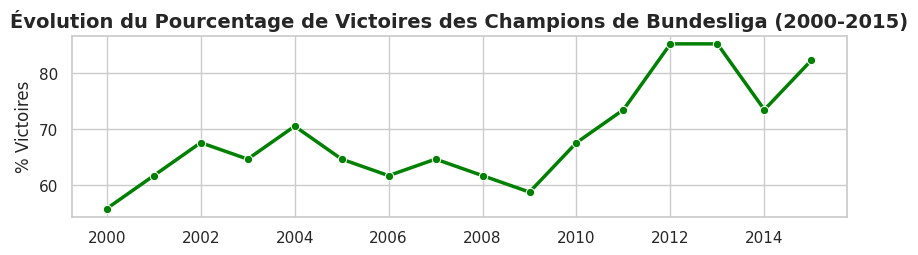

In [71]:
plt.figure(figsize=(10, 8))
plt.subplot(3, 1, 1)
sns.lineplot(data=df_champions_pd, x="Season", y="WinPercentage", marker="o", color="green", linewidth=2.5)
plt.title("Évolution du Pourcentage de Victoires des Champions de Bundesliga (2000-2015)", fontsize=14, fontweight='bold')
plt.ylabel("% Victoires")
plt.xlabel("")

 GRAPHIC 2 : Nombre de Buts Marqués par les Champions

/tmp/ipykernel_2298/983920903.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_champions_pd, x="Season", y="GoalsScored", palette="viridis")


Text(0.5, 0, '')

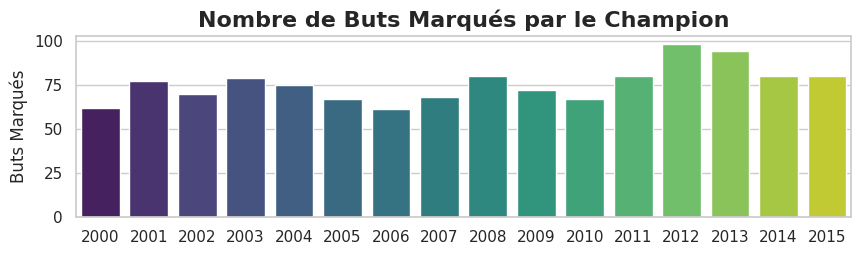

In [76]:
plt.figure(figsize=(10, 8))
plt.subplot(3, 1, 2)
sns.barplot(data=df_champions_pd, x="Season", y="GoalsScored", palette="viridis")
plt.title("Nombre de Buts Marqués par le Champion", fontsize=16, fontweight='bold')
plt.ylabel("Buts Marqués")
plt.xlabel("")

GRAPHIC 3 : Différence de Buts (Goal Differentials) par Saison

/tmp/ipykernel_2298/2393287324.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_champions_pd, x="Season", y="GoalDifferentials", palette="coolwarm")


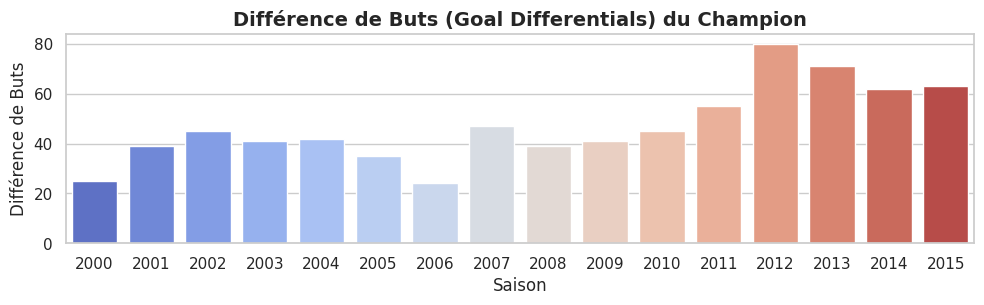

In [77]:
plt.figure(figsize=(10, 8))
plt.subplot(3, 1, 3)
sns.barplot(data=df_champions_pd, x="Season", y="GoalDifferentials", palette="coolwarm")
plt.title("Différence de Buts (Goal Differentials) du Champion", fontsize=14, fontweight='bold')
plt.ylabel("Différence de Buts")
plt.xlabel("Saison")

# Ajustement de l'espace entre les graphiques et affichage
plt.tight_layout()
plt.show()